# Import

In [1]:
import models.juanchitocnn
import models.visiontransformer
import models.efficientnetb0
import data_loader
import torch
from FGSM_attack import FGSMAttacker
from datetime import datetime
print('Import Done')
now = datetime.now()
print("Start:", now.strftime("%Y-%m-%d %H:%M:%S"))

C:\Users\Win\anaconda3\envs\cs7643-a4\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Import Done


# Settings and Hyperparameters

In [2]:
select_model = 'JuanchitoCNN' # ['EfficientNet', 'VisionTransformer', 'JuanchitoCNN']
train_original = True # Re-train model?
train_augmentation = True 
train_adversarial = True
train_augmentation_adversarial = True

# Model Hyperparameters
epochs = 5
learning_rate = 0.001
batch_size = 32
weight_decay = 0.01
momentum = 0.9
optimizer = 'SGD' # ['SGD', 'AdamW']

# Other parameters
train_test_split_ratio = 0.8
track_losses = True

In [3]:
#csv_path = '/home/hice1/jguardia7/scratch/datasets/alessandrasala79/ai-vs-human-generated-dataset/versions/4/train.csv'
#image_folder = '/home/hice1/jguardia7/scratch/datasets/alessandrasala79/ai-vs-human-generated-dataset/versions/4/train_data'

csv_path = 'data/train.csv'
image_folder = 'data/train_data'

# Only need to run cells below

## Selecting Model

In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

if select_model == 'EfficientNet':
    project_model = models.efficientnetb0.ProjectEfficientNet(epochs=epochs, learning_rate=learning_rate, batch_size=batch_size, optimizer=optimizer, momentum=momentum, weight_decay=weight_decay)
    project_model_aug = models.efficientnetb0.ProjectEfficientNet(epochs=epochs, learning_rate=learning_rate, batch_size=batch_size, optimizer=optimizer, momentum=momentum, weight_decay=weight_decay)
    project_model_adv = models.efficientnetb0.ProjectEfficientNet(epochs=epochs, learning_rate=learning_rate, batch_size=batch_size, optimizer=optimizer, momentum=momentum, weight_decay=weight_decay)
    project_model_aug_adv = models.efficientnetb0.ProjectEfficientNet(epochs=epochs, learning_rate=learning_rate, batch_size=batch_size, optimizer=optimizer, momentum=momentum, weight_decay=weight_decay)
    print(f'Using model {select_model}')
elif select_model == 'VisionTransformer':
    project_model = models.visiontransformer.ProjectVisionTransformer(epochs=epochs, learning_rate=learning_rate, batch_size=batch_size, optimizer=optimizer, momentum=momentum, weight_decay=weight_decay)
    project_model_aug = models.visiontransformer.ProjectVisionTransformer(epochs=epochs, learning_rate=learning_rate, batch_size=batch_size, optimizer=optimizer, momentum=momentum, weight_decay=weight_decay)
    project_model_adv = models.visiontransformer.ProjectVisionTransformer(epochs=epochs, learning_rate=learning_rate, batch_size=batch_size, optimizer=optimizer, momentum=momentum, weight_decay=weight_decay)
    project_model_aug_adv = models.visiontransformer.ProjectVisionTransformer(epochs=epochs, learning_rate=learning_rate, batch_size=batch_size, optimizer=optimizer, momentum=momentum, weight_decay=weight_decay)
    print(f'Using model {select_model}')
elif select_model == 'JuanchitoCNN':
    project_model = models.juanchitocnn.ProjectJuanchitoCNN(epochs=epochs, learning_rate=learning_rate, batch_size=batch_size, optimizer=optimizer, momentum=momentum, weight_decay=weight_decay)
    project_model_aug = models.juanchitocnn.ProjectJuanchitoCNN(epochs=epochs, learning_rate=learning_rate, batch_size=batch_size, optimizer=optimizer, momentum=momentum, weight_decay=weight_decay)
    project_model_adv = models.juanchitocnn.ProjectJuanchitoCNN(epochs=epochs, learning_rate=learning_rate, batch_size=batch_size, optimizer=optimizer, momentum=momentum, weight_decay=weight_decay)
    project_model_aug_adv = models.juanchitocnn.ProjectJuanchitoCNN(epochs=epochs, learning_rate=learning_rate, batch_size=batch_size, optimizer=optimizer, momentum=momentum, weight_decay=weight_decay)
    print(f'Using model {select_model}')
else:
    print('No valid model selected')

Using model JuanchitoCNN


## Train or Load Model on Regular Data

Batch Size: 32, Split Ratio: 0.8
Training on original data set


Evaluating loss at Epoch 1


Evaluating loss at Epoch 2


Evaluating loss at Epoch 3


Evaluating loss at Epoch 4


Evaluating loss at Epoch 5
Model state dictionary saved to: saved_models\JuanchitoCNN.pth


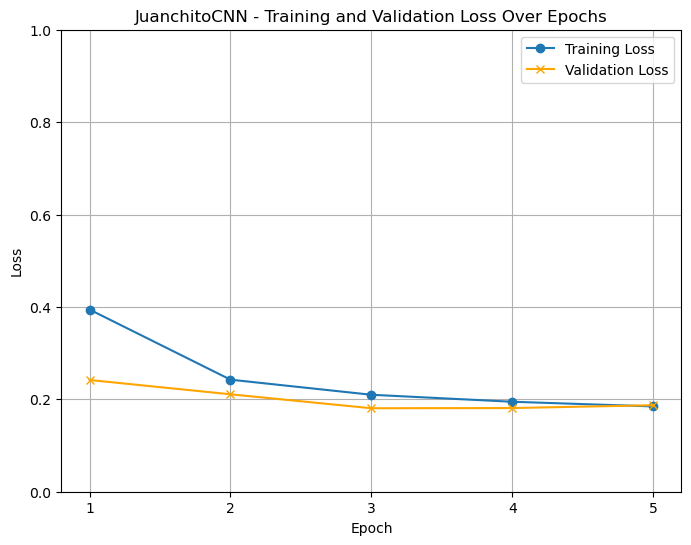

Training on augmented data set


Evaluating loss at Epoch 1


Evaluating loss at Epoch 2


Evaluating loss at Epoch 3


Evaluating loss at Epoch 4


Evaluating loss at Epoch 5
Model state dictionary saved to: saved_models\JuanchitoCNN_aug.pth


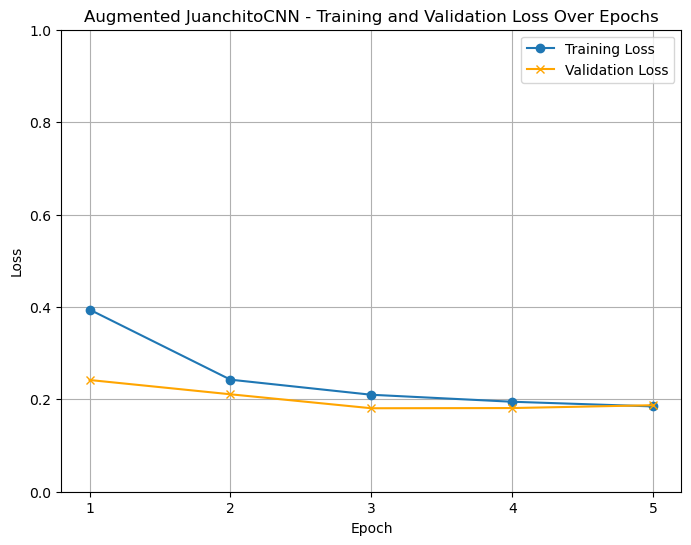

In [5]:

print(f'Batch Size: {batch_size}, Split Ratio: {train_test_split_ratio}')

if train_original == True:
    regular_train_loader, regular_test_loader = data_loader.data_to_train_test_dataloaders(csv_path=csv_path, 
                                                                                       image_folder=image_folder, 
                                                                                       image_size=(224, 224), 
                                                                                       split_ratio=train_test_split_ratio, 
                                                                                       train_batch_size=batch_size, 
                                                                                       test_batch_size=batch_size)

    project_model.data_load(regular_train_loader, regular_test_loader)
    print('Training on original data set')
    project_model.train(track_loss=track_losses)
    project_model.plot_losses(f'{select_model}')
elif train_original == False:
    project_model.model_load()
    print('Loaded with original data set')
    
if train_augmentation == True:
    regular_train_loader, regular_test_loader = data_loader.data_to_train_test_dataloaders(csv_path=csv_path, 
                                                                                       image_folder=image_folder, 
                                                                                       image_size=(224, 224), 
                                                                                       split_ratio=train_test_split_ratio, 
                                                                                       train_batch_size=batch_size, 
                                                                                       test_batch_size=batch_size)
    aug_train_loader, aug_test_loader = data_loader.data_to_aug_dataloaders(csv_path=csv_path, 
                                                                            image_folder=image_folder, 
                                                                            image_size=(224, 224), 
                                                                            split_ratio=train_test_split_ratio, 
                                                                            train_batch_size=batch_size, 
                                                                            test_batch_size=batch_size)

    project_model_aug.data_load(aug_train_loader, regular_test_loader)
    print('Training on augmented data set')
    project_model_aug.train(description='aug', track_loss=track_losses)
    project_model.plot_losses(f'Augmented {select_model}')
elif train_augmentation == False:
    project_model_aug.model_load(description='aug')
    print('Loaded with augmented data set')

Adversarial training on original data set


Evaluating loss at Epoch 1


Evaluating loss at Epoch 2


Evaluating loss at Epoch 3


Evaluating loss at Epoch 4


Evaluating loss at Epoch 5
Model state dictionary saved to: saved_models\JuanchitoCNN_adv.pth


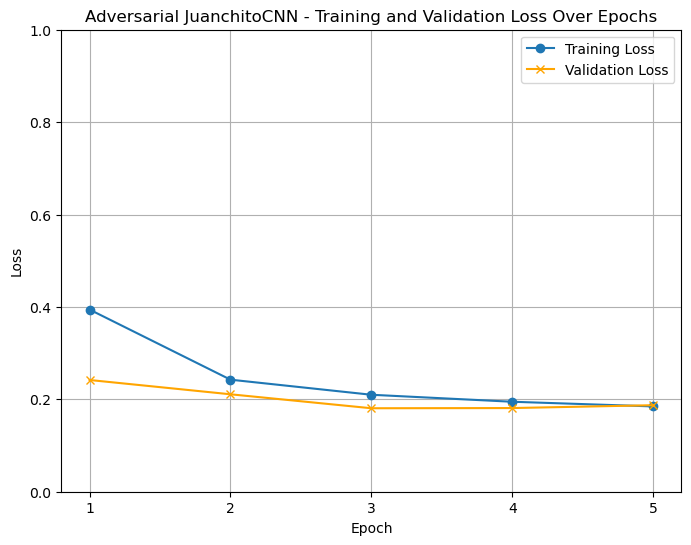

Adversarial training on augmented data set


Epoch 1/5:  89%|█████████████████████████████████████████████▌     | 1786/1999 [13:12<02:06,  1.68batch/s, loss=0.6946]

In [ ]:
if train_adversarial == True:
    regular_train_loader, regular_test_loader = data_loader.data_to_train_test_dataloaders(csv_path=csv_path, 
                                                                            image_folder=image_folder, 
                                                                            image_size=(224, 224), 
                                                                            split_ratio=train_test_split_ratio, 
                                                                            train_batch_size=batch_size, 
                                                                            test_batch_size=batch_size)

    project_model_adv.data_load(regular_train_loader, regular_test_loader)
    print('Adversarial training on original data set')
    project_model_adv.train_adversarial(description='adv', track_loss=track_losses)
    project_model.plot_losses(f'Adversarial {select_model}')
    
elif train_adversarial == False:
    project_model_adv.model_load(description='adv')
    print('Loaded with original data set')
    
if train_augmentation_adversarial == True:
    regular_train_loader, regular_test_loader = data_loader.data_to_train_test_dataloaders(csv_path=csv_path, 
                                                                            image_folder=image_folder, 
                                                                            image_size=(224, 224), 
                                                                            split_ratio=train_test_split_ratio, 
                                                                            train_batch_size=batch_size, 
                                                                            test_batch_size=batch_size)
    aug_train_loader, aug_test_loader = data_loader.data_to_aug_dataloaders(csv_path=csv_path, 
                                                                            image_folder=image_folder, 
                                                                            image_size=(224, 224), 
                                                                            split_ratio=train_test_split_ratio, 
                                                                            train_batch_size=batch_size, 
                                                                            test_batch_size=batch_size)

    project_model_aug.data_load(aug_train_loader, regular_test_loader)
    print('Adversarial training on augmented data set')
    project_model_aug.train_adversarial(description='aug_adv', track_loss=track_losses)
    project_model.plot_losses(f'Augmented Adversarial {select_model}')

elif train_augmentation_adversarial == False:
    project_model_aug.model_load(description='aug_adv')
    print('Loaded with augmented data set')

## Trial 1 - Trained with original train data, Evaluated on original test data

In [ ]:
print('Trial 1 - Trained with original train data, Evaluated on original test data')
regular_train_loader, regular_test_loader = data_loader.data_to_train_test_dataloaders(csv_path=csv_path, 
                                                                                       image_folder=image_folder, 
                                                                                       image_size=(224, 224), 
                                                                                       split_ratio=train_test_split_ratio, 
                                                                                       train_batch_size=batch_size, 
                                                                                       test_batch_size=batch_size)

project_model.data_load(regular_train_loader, regular_test_loader)
regular_correct, total, regular_incorrect_preds = project_model.evaluate()

## Trial 2 - Trained with original train data, Evaluated on perturbed test data

In [ ]:
print('Trial 2 - Trained with original train data, Evaluated on perturbed test data')
for attack_style in ['SaltAndPepper', 'Posterize', 'GaussNoise', 'RandomShadow']:

    attack_train_loader, attack_test_loader = data_loader.data_to_attack_dataloaders(csv_path=csv_path, 
                                                                                     image_folder=image_folder, 
                                                                                     image_size=(224, 224), 
                                                                                     split_ratio=train_test_split_ratio, 
                                                                                     train_batch_size=batch_size, 
                                                                                     test_batch_size=batch_size, 
                                                                                     attack_style=attack_style)
    
    project_model.data_load(None, attack_test_loader)
    print(f'Attack type is {attack_style}')
    attack_correct, total, attack_incorrect_preds = project_model.evaluate()

## Trial 3 - Trained with original train data, Evaluated on FGSM

In [ ]:
print('Trial 3 - Trained with original train data, Evaluated on FGSM')
for fgsm_epsilon in [0.01, 0.05, 0.1]:
    fgsm_train_loader, fgsm_test_loader = data_loader.data_to_train_test_dataloaders(csv_path=csv_path, 
                                                                                           image_folder=image_folder, 
                                                                                           image_size=(224, 224), 
                                                                                           split_ratio=train_test_split_ratio, 
                                                                                           train_batch_size=1, 
                                                                                           test_batch_size=1)
    
    attacker = FGSMAttacker(project_model.model, device)
    acc, adv_examples = attacker.attack(fgsm_test_loader, fgsm_epsilon)

## Trial 4 - Trained with augmented train data, Evaluated on FGSM

In [ ]:
print('Trial 4 - Trained with augmented train data, Evaluated on FGSM')
for fgsm_epsilon in [0.01, 0.05, 0.1]:
    fgsm_train_loader, fgsm_test_loader = data_loader.data_to_train_test_dataloaders(csv_path=csv_path, 
                                                                                           image_folder=image_folder, 
                                                                                           image_size=(224, 224), 
                                                                                           split_ratio=train_test_split_ratio, 
                                                                                           train_batch_size=1, 
                                                                                           test_batch_size=1)
    
    attacker = FGSMAttacker(project_model_aug.model, device)
    acc, adv_examples = attacker.attack(fgsm_test_loader, fgsm_epsilon)

## Trial 5 - Trained with adversarial train data, Evaluated on FGSM

In [ ]:
print('Trial 5 - Trained with adversarial train data, Evaluated on FGSM')
for fgsm_epsilon in [0.01, 0.05, 0.1]:
    fgsm_train_loader, fgsm_test_loader = data_loader.data_to_train_test_dataloaders(csv_path=csv_path, 
                                                                                           image_folder=image_folder, 
                                                                                           image_size=(224, 224), 
                                                                                           split_ratio=train_test_split_ratio, 
                                                                                           train_batch_size=1, 
                                                                                           test_batch_size=1)
    
    attacker = FGSMAttacker(project_model_adv.model, device)
    acc, adv_examples = attacker.attack(fgsm_test_loader, fgsm_epsilon)

## Trial 6 - Trained with augmented adversarial train data, Evaluated on FGSM

In [ ]:
print('Trial 6 - Trained with augmented adversarial train data, Evaluated on FGSM')
for fgsm_epsilon in [0.01, 0.05, 0.1]:
    fgsm_train_loader, fgsm_test_loader = data_loader.data_to_train_test_dataloaders(csv_path=csv_path, 
                                                                                           image_folder=image_folder, 
                                                                                           image_size=(224, 224), 
                                                                                           split_ratio=train_test_split_ratio, 
                                                                                           train_batch_size=1, 
                                                                                           test_batch_size=1)
    
    attacker = FGSMAttacker(project_model_aug_adv.model, device)
    acc, adv_examples = attacker.attack(fgsm_test_loader, fgsm_epsilon)

In [ ]:
now = datetime.now()
print("Finish:", now.strftime("%Y-%m-%d %H:%M:%S"))